# Customer Churn Prediction — Telecom Services

Predicting which telecom customers are likely to cancel their subscription (churn), so the business can step in early with a attractive offers.

## Section 1: Problem & Context

**Why churn matters.** Nowadays most of telecom companies are subscription based and making money so losing a customer isn't just one lost sale it’s about losing their all future payments It's also well known in the industry that it acquire a lot of cost and difficult to get a new customer than an existing customer. So if we can identify customers who are *about to* leave so the retention team can reach out to them with a discounts, offers something more on their current plan or just a support call before they cancel.

**How ML helps.** Instead of waiting for customers to churn we train a model on our previous customer data on people who already churned or stayed to find patterns like which contract types, tenure lengths, or add-on services are reasons why customers moving to other company. Then we use that model to calculate current customers and rank them by churn risk.

**About the data.** We're using the Telco Customer Churn dataset from Kaggle:

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

This is a view of customer’s accounts from a fake telecom company. Each row is one customer with columns describing their demographics (gender, senior citizen status), account info (tenure, contract type, payment method) the services signed up for phone, internet, streaming, tech support, etc and their charges. The target column is Churn which is Yes if the customer left in the last month and No. if they're still a customer. For modelling we'll convert this to 1 (churned) and 0 means stayed.

**The ML task** This is a binary classification problem for each customer predict `Churn = 1` or `Churn = 0`, and ideally also get a probability score so we can rank customers by risk instead of just yes/no.

## Section 2: Data Exploration & Quality Analysis (EDA)

Before I do anything else I want to just look at the data. How many rows and columns what type each column is and if something looks broken like missing values.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Dataset from: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv("file.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# check datatypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

One thing I noticed is `TotalCharges` is showing text not as number. That's weird because it should just be dollars. then I check for missing values in the normal way first and then find out why this column is not numeric.

In [19]:

print(df.isnull().sum().sum(), "missing values found by isnull()")

# TotalCharges is text, so maybe some rows are just empty spaces instead of a real NaN
blank_mask = df["TotalCharges"].str.strip() == ""
print("rows where TotalCharges is just blank:", blank_mask.sum())
df[blank_mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

0 missing values found by isnull()
rows where TotalCharges is just blank: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


So isnull() said 0 missing but that's only because these 11 rows have a blank string `" "` instead of NaN so pandas doesn't count it as missing. All 11 of them have `tenure = 0` which makes sense to me because they are brand new customers, first month so there is no total charge yet.

Now I'm going to check the target column itself

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


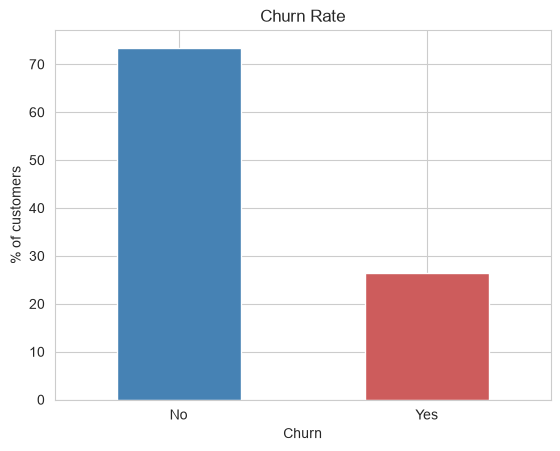

In [20]:
# how many customers churned vs stayed, in percent
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

churn_counts.plot(kind="bar", color=["steelblue", "indianred"])
plt.title("Churn Rate")
plt.ylabel("% of customers")
plt.xticks(rotation=0)
plt.show()

Around 26% of customers churned and 74% stayed. Not a big difference but still we have need to be careful with it.

As I just predicted "No churn" for literally every customer I would already get about 74% accuracy but this model is useless since it would never catch or detect the customer who are leaving. So accuracy by itself is not a good metric here it only hides current model doesn't have abilites to catch these kind of smaller class and which we care about.

Because of that I have to pay more attention to recall (out of the people who actually churned how many did the model catch, since missing a churner means we lose them for good) precision (out of the people the model flagged as risky, how many actually churned since sending out discounts costs money and we dont wanna spend resources on who were never leaving us) and ROC-AUC is a more general score of with how much precision the model tells churners and non-churners apart.

I'll try to fix this issue in our next section.

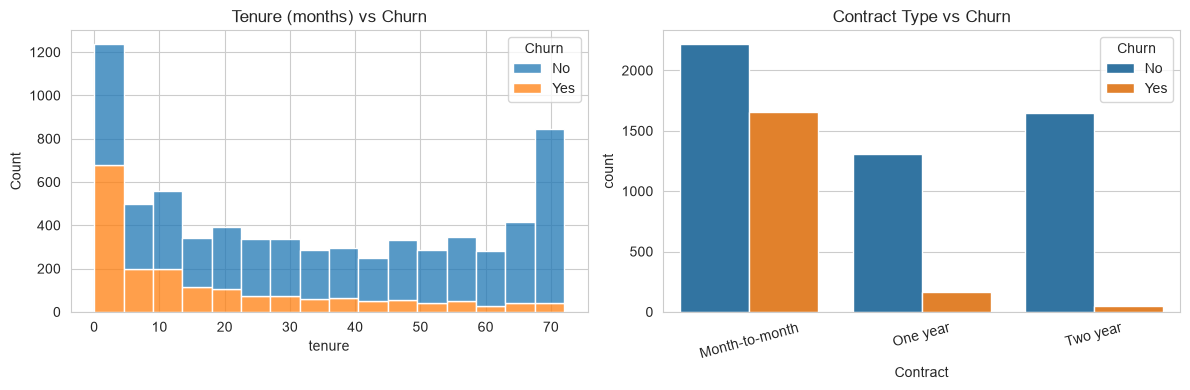

In [21]:
# quick look at tenure and contract type against churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", ax=axes[0])
axes[0].set_title("Tenure (months) vs Churn")

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[1])
axes[1].set_title("Contract Type vs Churn")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Two things comes to my mind here. Firstly, a lot of the churn happens in the first few months once the customers sticks around for a year or two they seem to less likely to leave us. Secondly, our montly customers churn way more than the ones on 1 year or 2 year contracts which kind a makes sense since a monthly plan costs nothing to cancel while a 2-year contract locks them more in it.

So `tenure` and `Contract` already look like important features,.

## Section 3: Preprocessing & Feature Engineering

Now I actually have to fix the problems which I found and ready the data for a model. So what I'm gonna doing is to fix `TotalCharges` drop the ID column because it isn't predicting anything and add 2 new features, turn the categories into numbers, scale the numeric columns, and finally split into train and test.

In [22]:
data = df.copy()

# turn the blank strings into NaN, then convert to number, then just fill with 0
# (these are the tenure=0 people, so 0 total charge makes sense anyway)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"].str.strip(), errors="coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(0)

# customerID is just a label, not useful for the model
data = data.drop(columns=["customerID"])

# turn target into 0/1 so the model can use it
data["Churn"] = (data["Churn"] == "Yes").astype(int)

print("missing values left:", data.isnull().sum().sum())
data[["tenure", "TotalCharges", "MonthlyCharges", "Churn"]].head()

missing values left: 0


,tenure,TotalCharges,MonthlyCharges,Churn
0,1,29.85,29.85,0
1,34,1889.50,56.95,0
2,2,108.15,53.85,1
3,45,1840.75,42.30,0
4,2,151.65,70.70,1


### Making 2 new features

Before moving further I want to add two small features.

Firstly, `tenure_group` which just puts together tenure months into years . I noticed in Section 2 that new customers churn a lot more so by putting tenure into year groups should make that pattern clear to the model especially for Logistic Regression.

Secondly, `total_services` which counts how many of the extra services such as OnlineBackup, DeviceProtection, TechSupport, StreamingTV, a customer actually turned on. My guess is customers with more add-ons feel more locked in and churn less.

In [23]:
# 1. group tenure (months) into years
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ["0-1yr", "1-2yr", "2-3yr", "3-4yr", "4-5yr", "5-6yr"]
data["tenure_group"] = pd.cut(data["tenure"], bins=bins, labels=labels, include_lowest=True)

# 2. count how many add-on services are turned on ("Yes")
addon_cols = ["OnlineBackup", "DeviceProtection",
              "TechSupport", "StreamingTV"]
data["total_services"] = (data[addon_cols] == "Yes").sum(axis=1)

data[["tenure", "tenure_group", "total_services"]].head()

,tenure,tenure_group,total_services
0,1,0-1yr,1
1,34,2-3yr,1
2,2,0-1yr,1
3,45,3-4yr,2
4,2,0-1yr,0


### Turning categories into numbers, scaling, and splitting

Models can only understand numbers so all the text columns `Contract`, `PaymentMethod`, `InternetService`, my new `tenure_group`, etc. turned to dummy 0/1 columns. The numeric columns (`tenure`, `MonthlyCharges`, `TotalCharges`, `total_services`) get scaled with `StandardScaler` so that one big-range column doesn't dominate the others especially for Logistic Regression.

One thing which I learned that's easy to mess up is  I split into train/test **before** scaling and only fit the scaler. If scale first and then split the test set will leak into the training process via the mean/std used for scaling.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# turn all text/category columns into dummy 0/1 columns
data_encoded = pd.get_dummies(data, drop_first=True)

X = data_encoded.drop(columns=["Churn"])
y = data_encoded["Churn"]

# split first, scale after, so test data doesn't leak into training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "total_services"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("train shape:", X_train.shape)
print("test shape:", X_test.shape)
print("train churn rate:", round(y_train.mean() * 100, 1), "%")
print("test churn rate:", round(y_test.mean() * 100, 1), "%")

train shape: (5634, 36)
test shape: (1409, 36)
train churn rate: 26.5 %
test churn rate: 26.5 %


## Section 4: Model Training & Hyperparameter Tuning

Now I want to try different models and see which one perform better. I'll start with 3 baselines using just the default settings no modifications yet: Logistic Regression as a simple starting point, Random Forest since tree based models usually perform well on this kind of data and Gradient Boosting which is usually one of the stronger options for this kind of problem.

After that I'll choose best tree model performs best among them and tune its hyperparameters using `GridSearchCV`.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [26]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
preds = log_reg.predict(X_test)
probs = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("precision:", round(precision_score(y_test, preds), 3))
print("recall:   ", round(recall_score(y_test, preds), 3))
print("f1:       ", round(f1_score(y_test, preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, probs), 3))

Logistic Regression
precision: 0.664
recall:    0.529
f1:        0.589
roc-auc:   0.843


In [27]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)
probs = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("precision:", round(precision_score(y_test, preds), 3))
print("recall:   ", round(recall_score(y_test, preds), 3))
print("f1:       ", round(f1_score(y_test, preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, probs), 3))

Random Forest
precision: 0.628
recall:    0.484
f1:        0.547
roc-auc:   0.82


In [28]:
# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
preds = gb.predict(X_test)
probs = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print("precision:", round(precision_score(y_test, preds), 3))
print("recall:   ", round(recall_score(y_test, preds), 3))
print("f1:       ", round(f1_score(y_test, preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, probs), 3))

Gradient Boosting
precision: 0.655
recall:    0.508
f1:        0.572
roc-auc:   0.842


Looking at the results all of the models are pretty close. Logistic Regression and Gradient Boosting both got a ROC-AUC of around 0.843, Random Forest was a bit lower at 0.82. Honestly I expected more from the tree models to beat plain Logistic Regression, with this dataset a simple linear model already does a decent job though probably because the strongest signals (tenure, contract type) are simple straightforward relationships.

Since the task is to tune a tree based model then I'll go with **Gradient Boosting** since it's the best tree model here (better than Random Forest on every metric). I'll use `GridSearchCV` to make search over a few basic hyperparameters: `n_estimators`, `max_depth`, and `learning_rate`.

In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1],
}

grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, scoring="roc_auc", cv=5)
grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("best cv roc-auc:", round(grid.best_score_, 3))

best_model = grid.best_estimator_

best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
best cv roc-auc: 0.848


selected research `learning_rate=0.05`, `max_depth=3`, `n_estimators=100` with a cross-validated ROC-AUC of about 0.848. That's a slight small improvement over the default Gradient Boosting model (0.842) so the tuning did help but  not at a large scale. I'll use this `best_model` for the final evaluation in Section 5.

## Section 5: Model Assessment

Now its time to check how our tuned model actually does on the test set the 20% of data it has never seen. While having a look at precision recall, f1 and ROC-AUC again then plot a confusion matrix and an ROC curve so I can actually know what's going on instead of just staring at numbers.

In [30]:
test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

print("precision:", round(precision_score(y_test, test_preds), 3))
print("recall:   ", round(recall_score(y_test, test_preds), 3))
print("f1:       ", round(f1_score(y_test, test_preds), 3))
print("roc-auc:  ", round(roc_auc_score(y_test, test_probs), 3))

precision: 0.655
recall:    0.487
f1:        0.558
roc-auc:   0.846


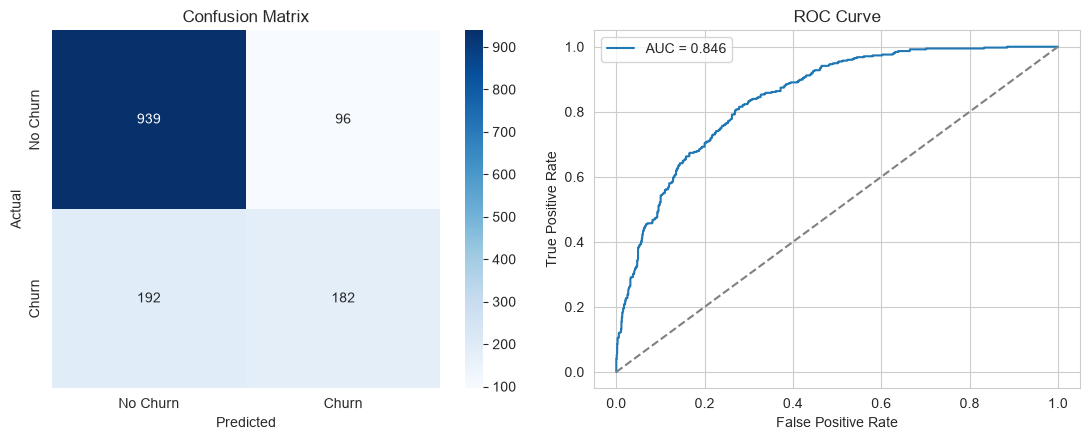

In [31]:
from sklearn.metrics import confusion_matrix, roc_curve, auc

cm = confusion_matrix(y_test, test_preds)
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc_value = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[1].plot(fpr, tpr, label="AUC = " + str(round(roc_auc_value, 3)))
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

On the test set the model got precision 0.655, recall 0.487, f1 0.558 and roc-auc 0.846. So it's basically in line with what's the cross-validation during tuning predicted which is good it means the model is not performing badly.

confusion matrix shows that 182 out of 374 customers who actually churned in the test set were correctly identified by the model and 192 were missed. It also identified that  96 people as churn risks who did not churn. So right now the model start catches  half of the real churners which is not amazing but every one from 182 is a customer the retention team gets a chance to save that they have  otherwise lost them  with no warning at all.

This is exactly the precision vs recall trade-off I mentioned before in Section 2. If the business wants to catch more from 192 churners which we're currently missing then we could have to lower the decision threshold (instead of the default 0.5) so the model flags more people as risky which improves recall but also raise the number of false alarms leads to  more discounts given out to people who were never going to leave which costs money. Exactly set that threshold really depends on how much a retention offer costs or how much amount the lost customer costs the company which is a business decision rather than a purely technical one.

## Section 6: Discussion, Business Recommendations & Deployment

Now what I have a trained and tested model. Let me think about what this actually means for the business its not just the raw numbers.

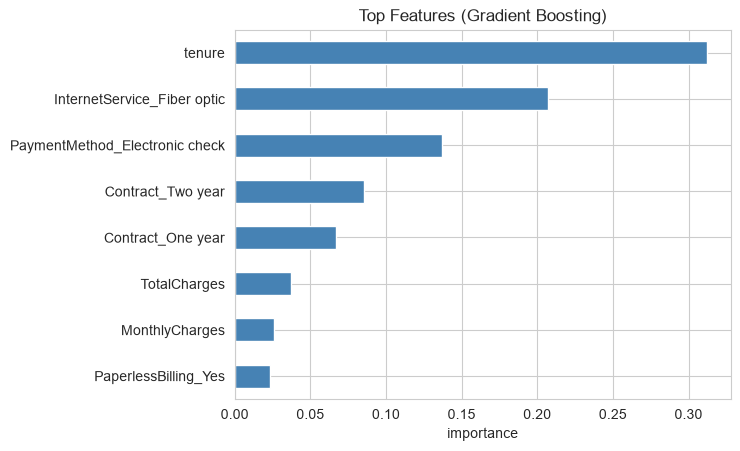

In [32]:
# check which features the model actually relies on
importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(8)

top_features.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Top Features (Gradient Boosting)")
plt.xlabel("importance")
plt.show()

By far the biggest driver is `tenure` then having Fiber optic internet then paying by electronic check then having on a 1 or 2 year contract these lines what I already consistenly noticed back in Section 2 regarding tenure and contract type so to ensure that the model is detecting on real patterns and not something weird. Since it's a tree based model with a manageable number of features I can just read off these importance things directly so I wouldd call this reasonably explainable not a total black box.

Strengths and limitations: the model gets a decent ROC-AUC of 0.846 so it's fairly good at ranking who is more or less likely to churn. But recall is still under 50%, so more than half the actual churners are not being caught. I would call this a solid first version but not a finished or good solution according to me. Things I would try next time in future are  testing other thresholds instead of the default 0.5, trying SMOTE or class weights to deal with the imbalance more directly and maybe adding features like number of support calls if that data existed.

Business recommendations: since contract type and tenure matter important I would like to give advice to the company to have more focus  on month-to-month customers in their first year because its the highest risk group. For customers who also have fiber optic internet or pay by electronic check a proactive call or a discount to move them onto a longer contract seems like a reasonable first step rather than using a strict yes/no cutoff. I would rank customers according to the model's probability score and write the list and give to retention team, starting with the highest risk customers, especially since the team likely has a limited budget for retention offers.

Deployment: I think this is something done through batch scoring not in real time. Churn is not something that needs an instant reaction so scoring the full customer list once a week or a month and handing it to retention team a ranked list should work fine. Before actually deploying anything I would want to check the model again on newer data every few months, since customer behaviour and pricing plans can change over time.

## References

BlastChar (n.d.) *Telco Customer Churn* [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn (Accessed: 14 September 2026).

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.